# Joining BM Olink data with Subject/Sample meta data 

In [2]:
library(tidyverse)
library(readxl)
library(janitor)
library(magrittr)
library(skimr)
library(gt)
library(hise)
library(lubridate)

#library(mice)
source('../00-utilities/functions/00_functions_data_loading.R')
file.sources <- list.files(
    path = "./ndmmFH1_helper_functions", 
    pattern = "\\.R$", full.names = TRUE
)
file.sources
# Source each R file
invisible(sapply(file.sources, source))

[1] "./ndmmFH1_helper_functions/data_crud.R" 
[2] "./ndmmFH1_helper_functions/data_manip.R"
[3] "./ndmmFH1_helper_functions/data_vis.R"  
[4] "./ndmmFH1_helper_functions/misc.R"      
[5] "./ndmmFH1_helper_functions/static.R"

Load the local csv file of the checked bm olink data file and the provided excel file with meta data. 

# Load Data 
##  Batch 1 BMIF Olink Data 

In [4]:
## Olink BMIF Data 
olink_bmif <- fread('../../data/olink/BMIF_Olink_Samples_batch1.csv', data.table=F)

[1] 500310     24

,108871,108872,108873,108874,108875,108876
SampleID,BMIF02603-001-001,BMIF02604-001-003,SUP02433-001-003,SUP02438-001-003,BMIF04753-001-001,BMIF02617-001-001
Sample_Type,SAMPLE,SAMPLE,SAMPLE,SAMPLE,SAMPLE,SAMPLE
Index,1,2,3,4,6,7
OlinkID,OID20602,OID20602,OID20602,OID20602,OID20602,OID20602
UniProt,Q9NQ25,Q9NQ25,Q9NQ25,Q9NQ25,Q9NQ25,Q9NQ25
Assay,SLAMF7,SLAMF7,SLAMF7,SLAMF7,SLAMF7,SLAMF7
MissingFreq,0.2711,0.2711,0.2711,0.2711,0.2711,0.2711
Panel,Inflammation,Inflammation,Inflammation,Inflammation,Inflammation,Inflammation
Panel_Lot_Nr,E50006,E50006,E50006,E50006,E50006,E50006
PlateID,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887


## Olink Sample Metadata 

In [5]:
## Olink Sample Metadata 
## metadata sample list: 89ce8979-fa81-4e3b-840a-efe03d760f32
 
file_id = list('f4928a1c-ef0b-43c3-a37e-d07491873341')
paths <- hise::cacheFiles(fileIds = file_id)

In [7]:
### Read file from HISE
olink_metadata <- fread(paths[1], data.table=F)

[1] 989  19

,Sample Format,Sample Type,AIFI Barcode,Subject,Sex,Age,Race,Plate #,Cohort,Diease/ Treatment condition,Collection Date,Year 1-3 or Year 4?,Location (lctn_barCode),Located At Row,Located At Column,Volume,V17,V18,V19
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<lgl>,<lgl>,<lgl>
1,BMIF,BC 10/20/23 Ig Depleted,BMIF06062-028-001,AC1003,M,26,Other,1,AllCells,Normal BMIF (Bridging Control),N/A,N/A,BX-01141,A,3,50,NA,NA,NA
2,BMIF,BC 10/20/23 Ig Non depleted,BMIF06062-028-003,AC1003,M,26,Other,1,AllCells,Normal BMIF (Bridging Control),N/A,N/A,BX-00881,A,9,50,NA,NA,NA


[1] "Sample Format"               "Sample Type"                
 [3] "AIFI Barcode"                "Subject"                    
 [5] "Sex"                         "Age"                        
 [7] "Race"                        "Plate #"                    
 [9] "Cohort"                      "Diease/ Treatment condition"
[11] "Collection Date"             "Year 1-3 or Year 4?"        
[13] "Location (lctn_barCode)"     "Located At Row"             
[15] "Located At Column"           "Volume"                     
[17] "V17"                         "V18"                        
[19] "V19"

In [8]:
### keep only bone marrow interstitial fluid samples
olink_metadata = olink_metadata[olink_metadata$`Sample Format`=='BMIF',]

### remove excess empty columns 
### that were included in metadata
olink_metadata <- olink_metadata[, !colnames(olink_metadata) %in% c('V17','V18','V19')]

### check for expected # of samples & dimensions
dim(olink_metadata)

[1] 166  16

,Sample Format,Sample Type,AIFI Barcode,Subject,Sex,Age,Race,Plate #,Cohort,Diease/ Treatment condition,Collection Date,Year 1-3 or Year 4?,Location (lctn_barCode),Located At Row,Located At Column,Volume
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,BMIF,BC 10/20/23 Ig Depleted,BMIF06062-028-001,AC1003,M,26,Other,1,AllCells,Normal BMIF (Bridging Control),N/A,N/A,BX-01141,A,3,50
2,BMIF,BC 10/20/23 Ig Non depleted,BMIF06062-028-003,AC1003,M,26,Other,1,AllCells,Normal BMIF (Bridging Control),N/A,N/A,BX-00881,A,9,50


# Data Overview

Explore # of samples & data in
bone marrow interstitial fluid files

In [9]:
head(olink_bmif)
colnames(olink_bmif)

,SampleID,Sample_Type,Index,OlinkID,UniProt,Assay,MissingFreq,Panel,Panel_Lot_Nr,PlateID,⋯,Assay_Warning,ExploreVersion,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid,is_technical_control
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<IDate>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>
1,BMIF02603-001-001,SAMPLE,1,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,PASS,2001-03-08,FH1,FH1017,Female,Other - Non-Flu,MM Pre-Treatment,0,KT02603,FALSE
2,BMIF02604-001-003,SAMPLE,2,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,PASS,2001-03-08,FH1,FH1018,Male,Other - Non-Flu,MM Pre-Treatment,0,KT02604,FALSE
3,SUP02433-001-003,SAMPLE,3,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,PASS,2001-03-08,FH1,FH1008,Female,Other - Non-Flu,MM End Induction 1st Draw,248,KT02433,FALSE
4,SUP02438-001-003,SAMPLE,4,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,PASS,2001-03-08,FH1,FH1011,Male,Other - Non-Flu,MM End Induction 1st Draw,143,KT02438,FALSE
5,BMIF04753-001-001,SAMPLE,6,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,PASS,2001-03-08,FH1,FH1011,Male,Other - Non-Flu,MM Post Transplant 1 year,517,KT04753,FALSE
6,BMIF02617-001-001,SAMPLE,7,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,PASS,2001-03-08,FH1,FH1018,Male,Other - Non-Flu,MM Post Transplant 90 Days,264,KT02617,FALSE


[1] "SampleID"             "Sample_Type"          "Index"               
 [4] "OlinkID"              "UniProt"              "Assay"               
 [7] "MissingFreq"          "Panel"                "Panel_Lot_Nr"        
[10] "PlateID"              "QC_Warning"           "LOD"                 
[13] "NPX"                  "Normalization"        "Assay_Warning"       
[16] "ExploreVersion"       "Cohort"               "Subject"             
[19] "Sex"                  "VisitName"            "VisitDetails"        
[22] "DaysSinceFirstVisit"  "SampleKitGuid"        "is_technical_control"

Overview of missing values in the meta file

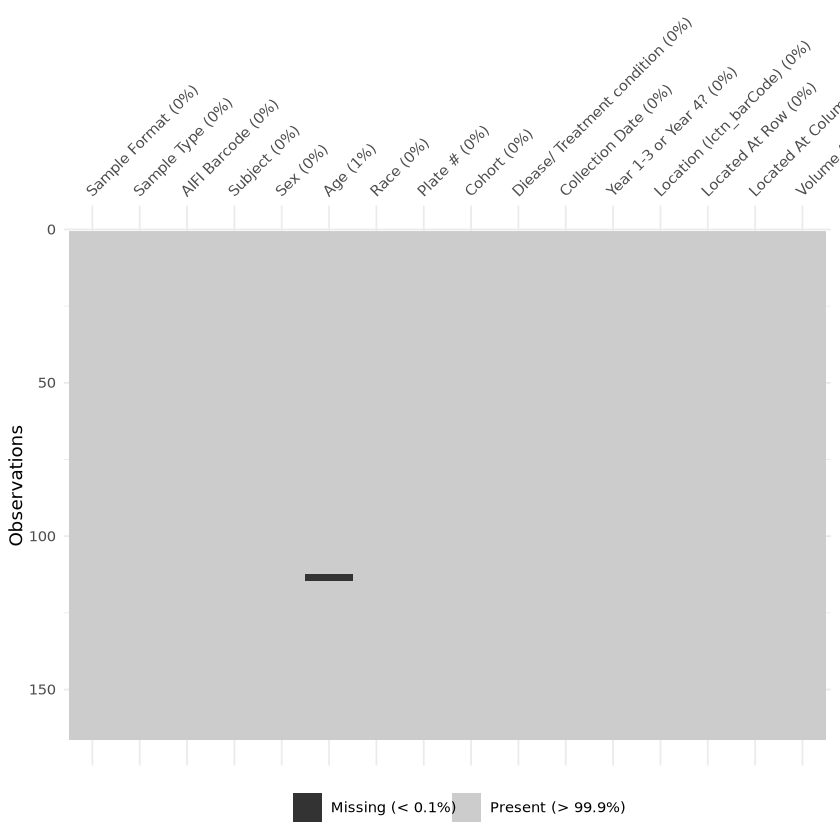

In [10]:
naniar::vis_miss(olink_metadata)

Inspect rows with missing values

In [12]:
olink_metadata %>% 
  filter(if_any(everything(), is.na)) 

Sample Format,Sample Type,AIFI Barcode,Subject,Sex,Age,Race,Plate #,Cohort,Diease/ Treatment condition,Collection Date,Year 1-3 or Year 4?,Location (lctn_barCode),Located At Row,Located At Column,Volume
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
BMIF,Ig Depleted,BMIF02442-001-001,FH1015,,NA,,1,FH1,MM Pre-Treatment,06/29/2021 10:55:00,Y1-3,BX-00881,D,2,50
BMIF,Ig Non depleted,BMIF02442-001-003,FH1015,,NA,,1,FH1,MM Pre-Treatment,06/29/2021 10:55:00,Y1-3,BX-00881,A,1,50


We can see that among rows with any na value, all but two are indicated to be bridging controls in visit. 
There are two sampleIDs (BMIF02442-001-001 and BMIF02442-001-003) indicated to be MM Pre-Treatment. They are the same subject (FH1015). The reason there are two sampleIDs, is that it was run Ig depleted and non Ig depleted. 

# Data Transformations

## Transforming collection date var into MDY_HMS

In [13]:
olink_metadata$`Collection Date` <- lubridate::mdy_hms(olink_metadata$`Collection Date`)

Warning message:
“ 22 failed to parse.”


In [14]:
### we check that the 22 samples without 
### sample collection dates are samples from
### the 'all cells' cohort, not the FH NDMM cohort
table(olink_metadata[is.na(olink_metadata$`Collection Date`), ]$Cohort, useNA = 'always')
table(olink_metadata[!is.na(olink_metadata$`Collection Date`), ]$Cohort, useNA = 'always')


AllCells     <NA> 
      22        0 


 FH1 <NA> 
 144    0 

## Joining BM Samples and Meta Data

First we will check if identifiers are missing in any source. As can be seen, all samples are present in both files. The olink data file contains control samples as well which are not represented in the meta data. 

In [15]:
### confirm all human samples are in metadata file
mean(olink_bmif[olink_bmif$is_technical_control==F,]$SampleID %in% olink_metadata$`AIFI Barcode`)

### confirm all metadata files are in human data
mean(olink_metadata$`AIFI Barcode` %in% olink_bmif[olink_bmif$is_technical_control==F,]$SampleID)

[1] 1

[1] 1

### Column Naming Alignment BM Samples

Before Joining, column naming need to be aligned. Columns will be unified with the renaming vector below. 

In [16]:
rename_vector <- c(
  # Matching or similar columns unified
  "SampleID" = "SampleID",
  "Sample_Type" = "SampleType",
  "Index" = "Index",
  "OlinkID" = "OlinkID",
  "UniProt" = "UniProt",
  "Assay" = "Assay",
  "MissingFreq" = "MissingFreq",
  "Panel" = "Panel",
  "Panel_Lot_Nr" = "PanelLotNr",
  "PlateID" = "PlateID",
  "UniqueAssay" = "UniqueAssay",
  "BatchOffset" = "BatchOffset",
  "NPX" = "NPX",
  "LOD" = "LOD",
  "BridgingDetails" = "BridgingDetails",
  "filename" = "Filename",
  "BatchID" = "BatchID",
  
  # Columns without direct matches, capitalized and standardized
  "Sample Format" = "SampleFormat",
  "AIFI Barcode" = "SampleID", # AIFI Barcode matches SampleID
  "Subject" = "Subject",
  "Sex" = "Sex",
  "Age" = "Age",
  "Race" = "Race",
  "Plate #" = "PlateID",
  "Cohort" = "Cohort",
  "Diease/ Treatment condition" = "Visit", # This is where vis information is 
  "Collection Date" = "CollectionDate",
  "Year 1-3 or Year 4?" = "YearGroup",
  "Location (lctn_barCode)" = "LocationBarcode",
  "Located At Row" = "LocatedAtRow",
  "Located At Column" = "LocatedAtColumn",
  "Volume" = "Volume",
  
  # Columns in samples not directly matched, but needing standardization
  "ExploreVersion" = "ExploreVersion",
  "Normalization" = "Normalization",
  "Assay_Warning" = "AssayWarning"
)

olink_metadata %<>% column_map(mapping = rename_vector, delete.missing = F)
olink_bmif %<>% column_map(mapping = rename_vector, delete.missing = F)

In [18]:
janitor::compare_df_cols(olink_bmif, olink_metadata) %>% 
  gt() %>%
    sub_missing() %>%
    tab_header(title = "Common Columns in Data and Meta Files for BM Olink Data After Naming Alignment") %>% 
    gt::tab_footnote(footnote = "Data will be joined on SampleID") %>% 
    gt:::as.tags.gt_tbl()

Shiny tags cannot be represented in plain text (need html)

### Join Data File and Meta Data File for Bone Marrow Samples

To Ensure correct joining, ensure the data type of the joining column is correct. 

In [19]:
olink_metadata %<>% mutate(SampleID = as.factor(SampleID))
olink_bmif %<>% mutate(SampleID = as.factor(SampleID))
dim(olink_metadata)
dim(olink_bmif)

[1] 166  16

[1] 500310     24

In [20]:
olink_bmif_joined <- left_join(olink_bmif, 
                               olink_metadata[,!colnames(olink_metadata) %in% c('Cohort','Subject','Sex', 'PlateID')], 
                                  by = "SampleID")

dim(olink_bmif_joined)



[1] 500310     35

Check the common value table of the joined samples

In [21]:
str(olink_bmif_joined)

'data.frame':	500310 obs. of  35 variables:
 $ SampleID            : Factor w/ 178 levels "BMIF02087-001-001",..: 9 12 146 156 45 21 144 161 163 22 ...
 $ SampleType          : chr  "SAMPLE" "SAMPLE" "SAMPLE" "SAMPLE" ...
 $ Index               : int  1 2 3 4 6 7 8 9 10 11 ...
 $ OlinkID             : chr  "OID21161" "OID21161" "OID21161" "OID21161" ...
 $ UniProt             : chr  "P22307" "P22307" "P22307" "P22307" ...
 $ Assay               : chr  "SCP2" "SCP2" "SCP2" "SCP2" ...
 $ MissingFreq         : num  0.753 0.753 0.753 0.753 0.753 0.753 0.753 0.753 0.753 0.753 ...
 $ Panel               : chr  "Oncology" "Oncology" "Oncology" "Oncology" ...
 $ PanelLotNr          : chr  "B23406" "B23406" "B23406" "B23406" ...
 $ PlateID             : chr  "Q-11665_SS230887" "Q-11665_SS230887" "Q-11665_SS230887" "Q-11665_SS230887" ...
 $ QC_Warning          : chr  "PASS" "PASS" "PASS" "PASS" ...
 $ LOD                 : num  0.414 0.414 0.414 0.414 0.414 ...
 $ NPX                 : num  0.46

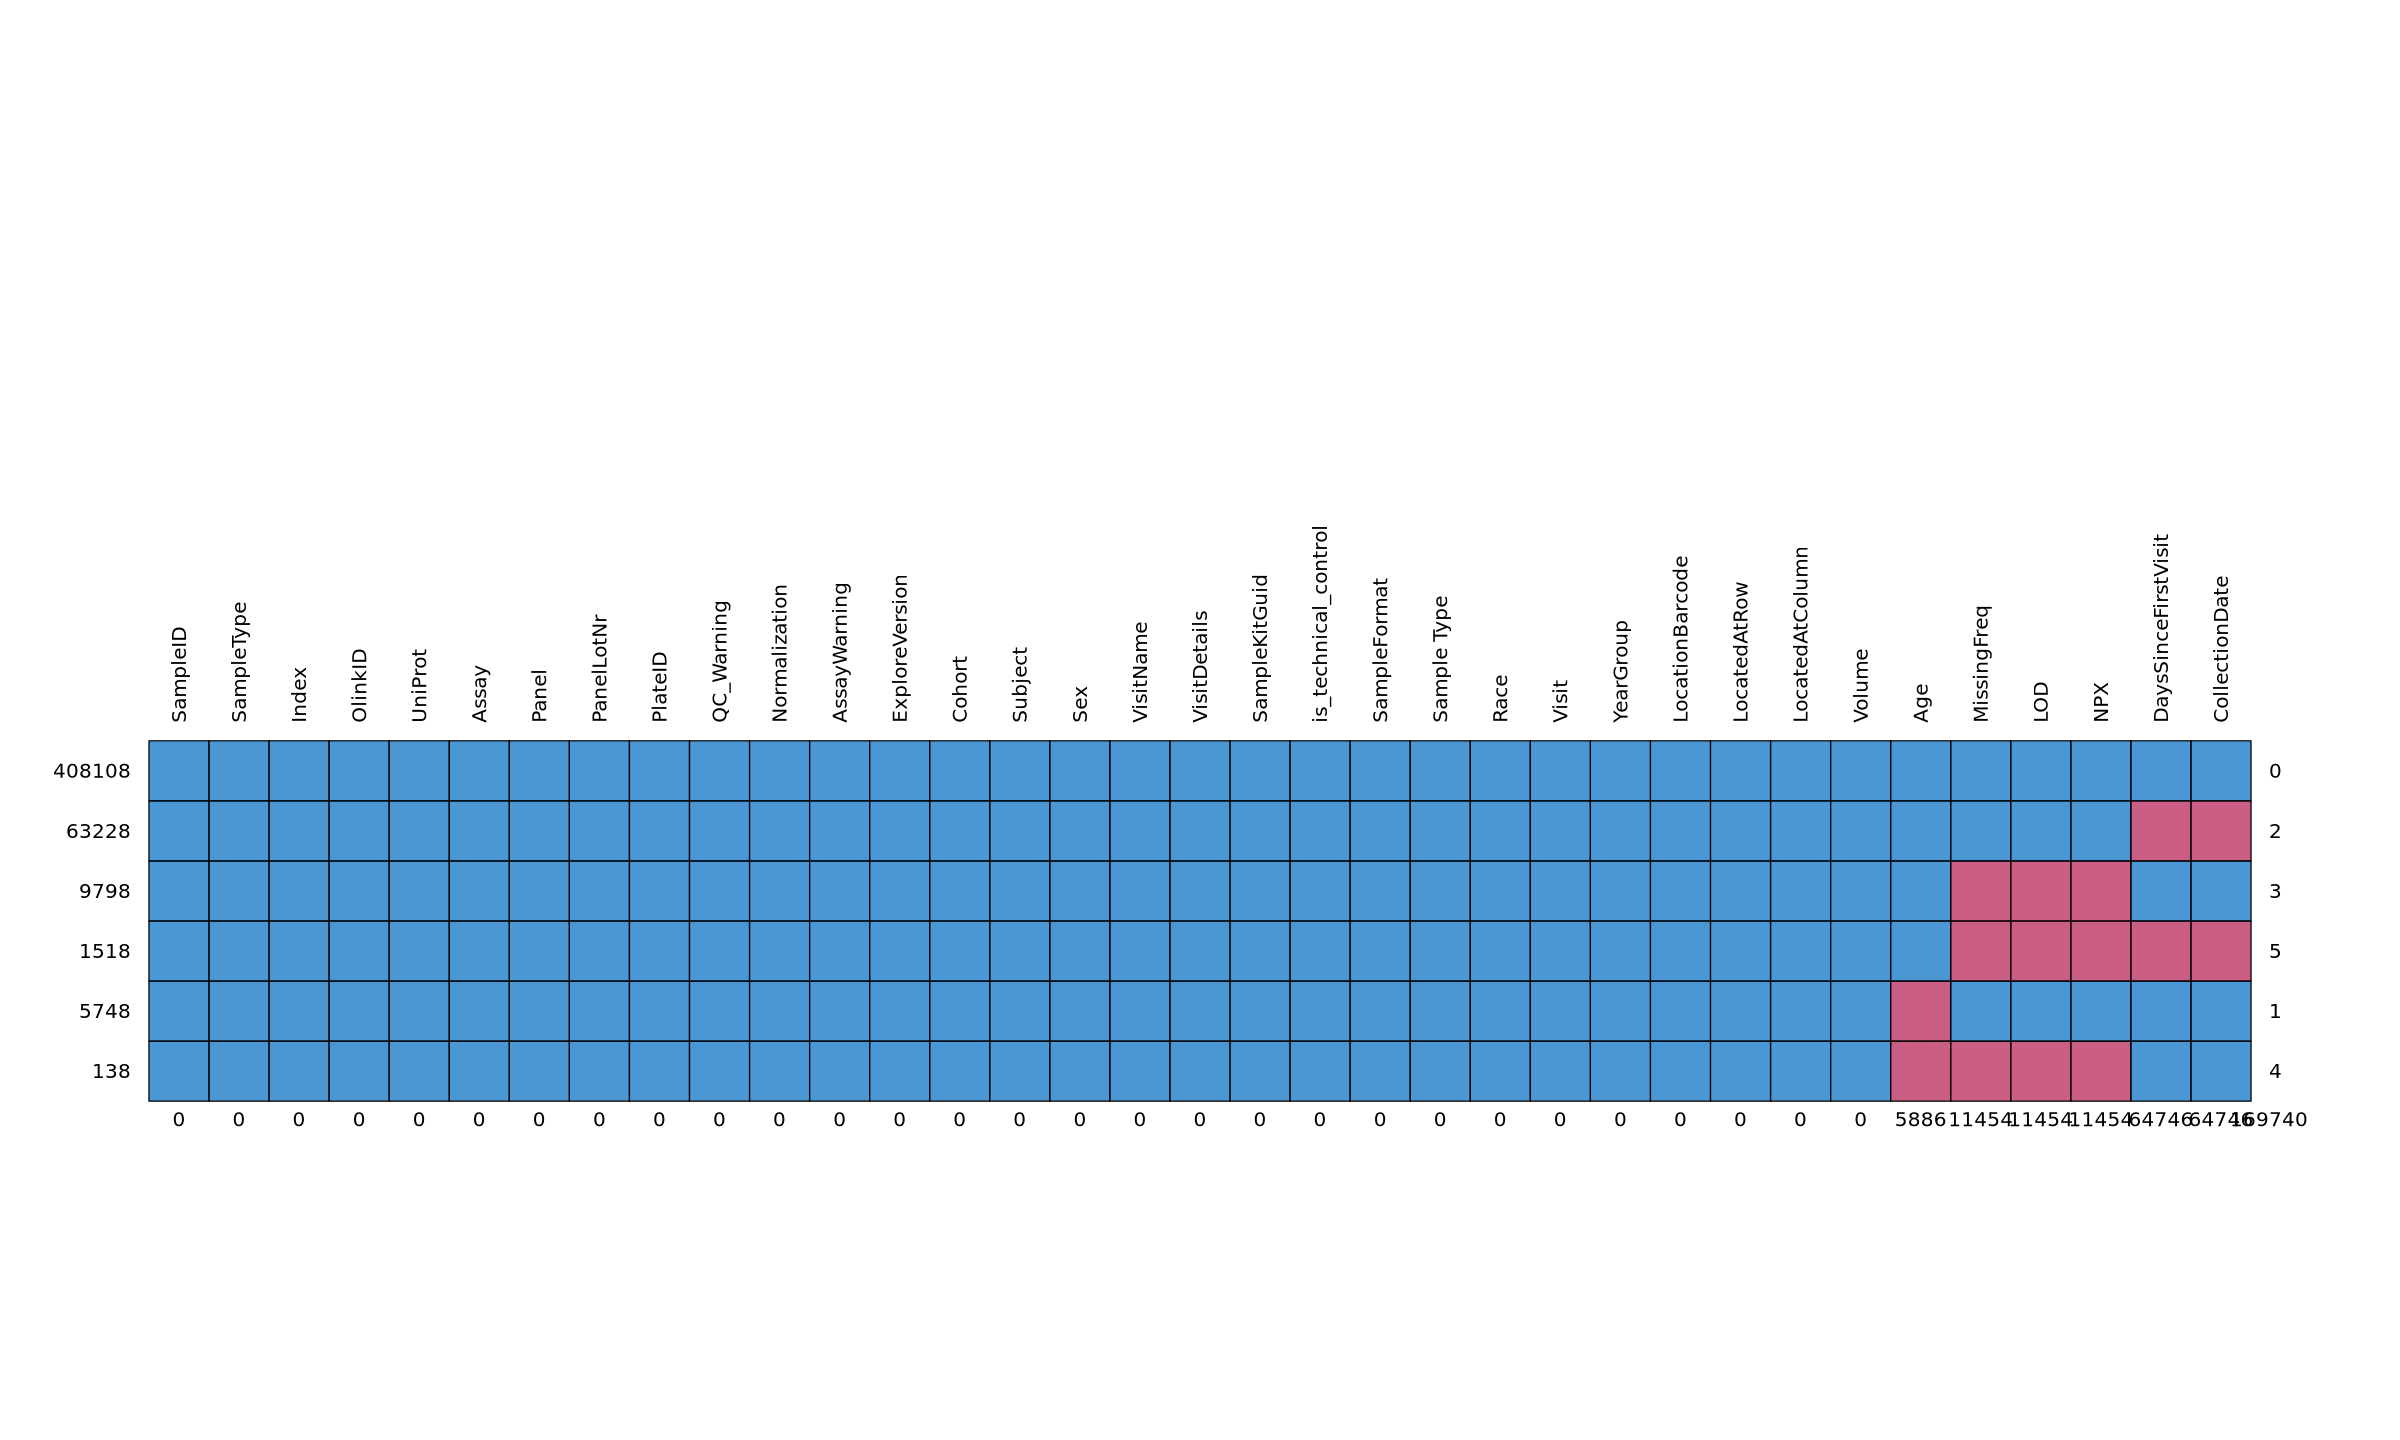

In [22]:
options(repr.plot.width = 20, repr.plot.height = 12)
md_pattern.samples <- olink_bmif_joined %>% 
  filter(SampleType == "SAMPLE") %>%
  mice::md.pattern(rotate.names = TRUE, plot = TRUE)

Heatmap of pattern of missing data among samples in the joined tibble. Each row show the number of rows with that pattern of missingness among variables. 
We can see that most variables are complete. Among some samples, Sex, Age and Race is missing and likely attirbutable to the one subject seen above. In some samples, the assay did not work out and NPX, LOD and MissingFreq is missing. The commonest missingness is CollectionDate and YearGroup. 

In [23]:
md_pairs.samples <- olink_bmif_joined %>% 
  filter(SampleType == "SAMPLE") %>%
  mice::md.pairs()

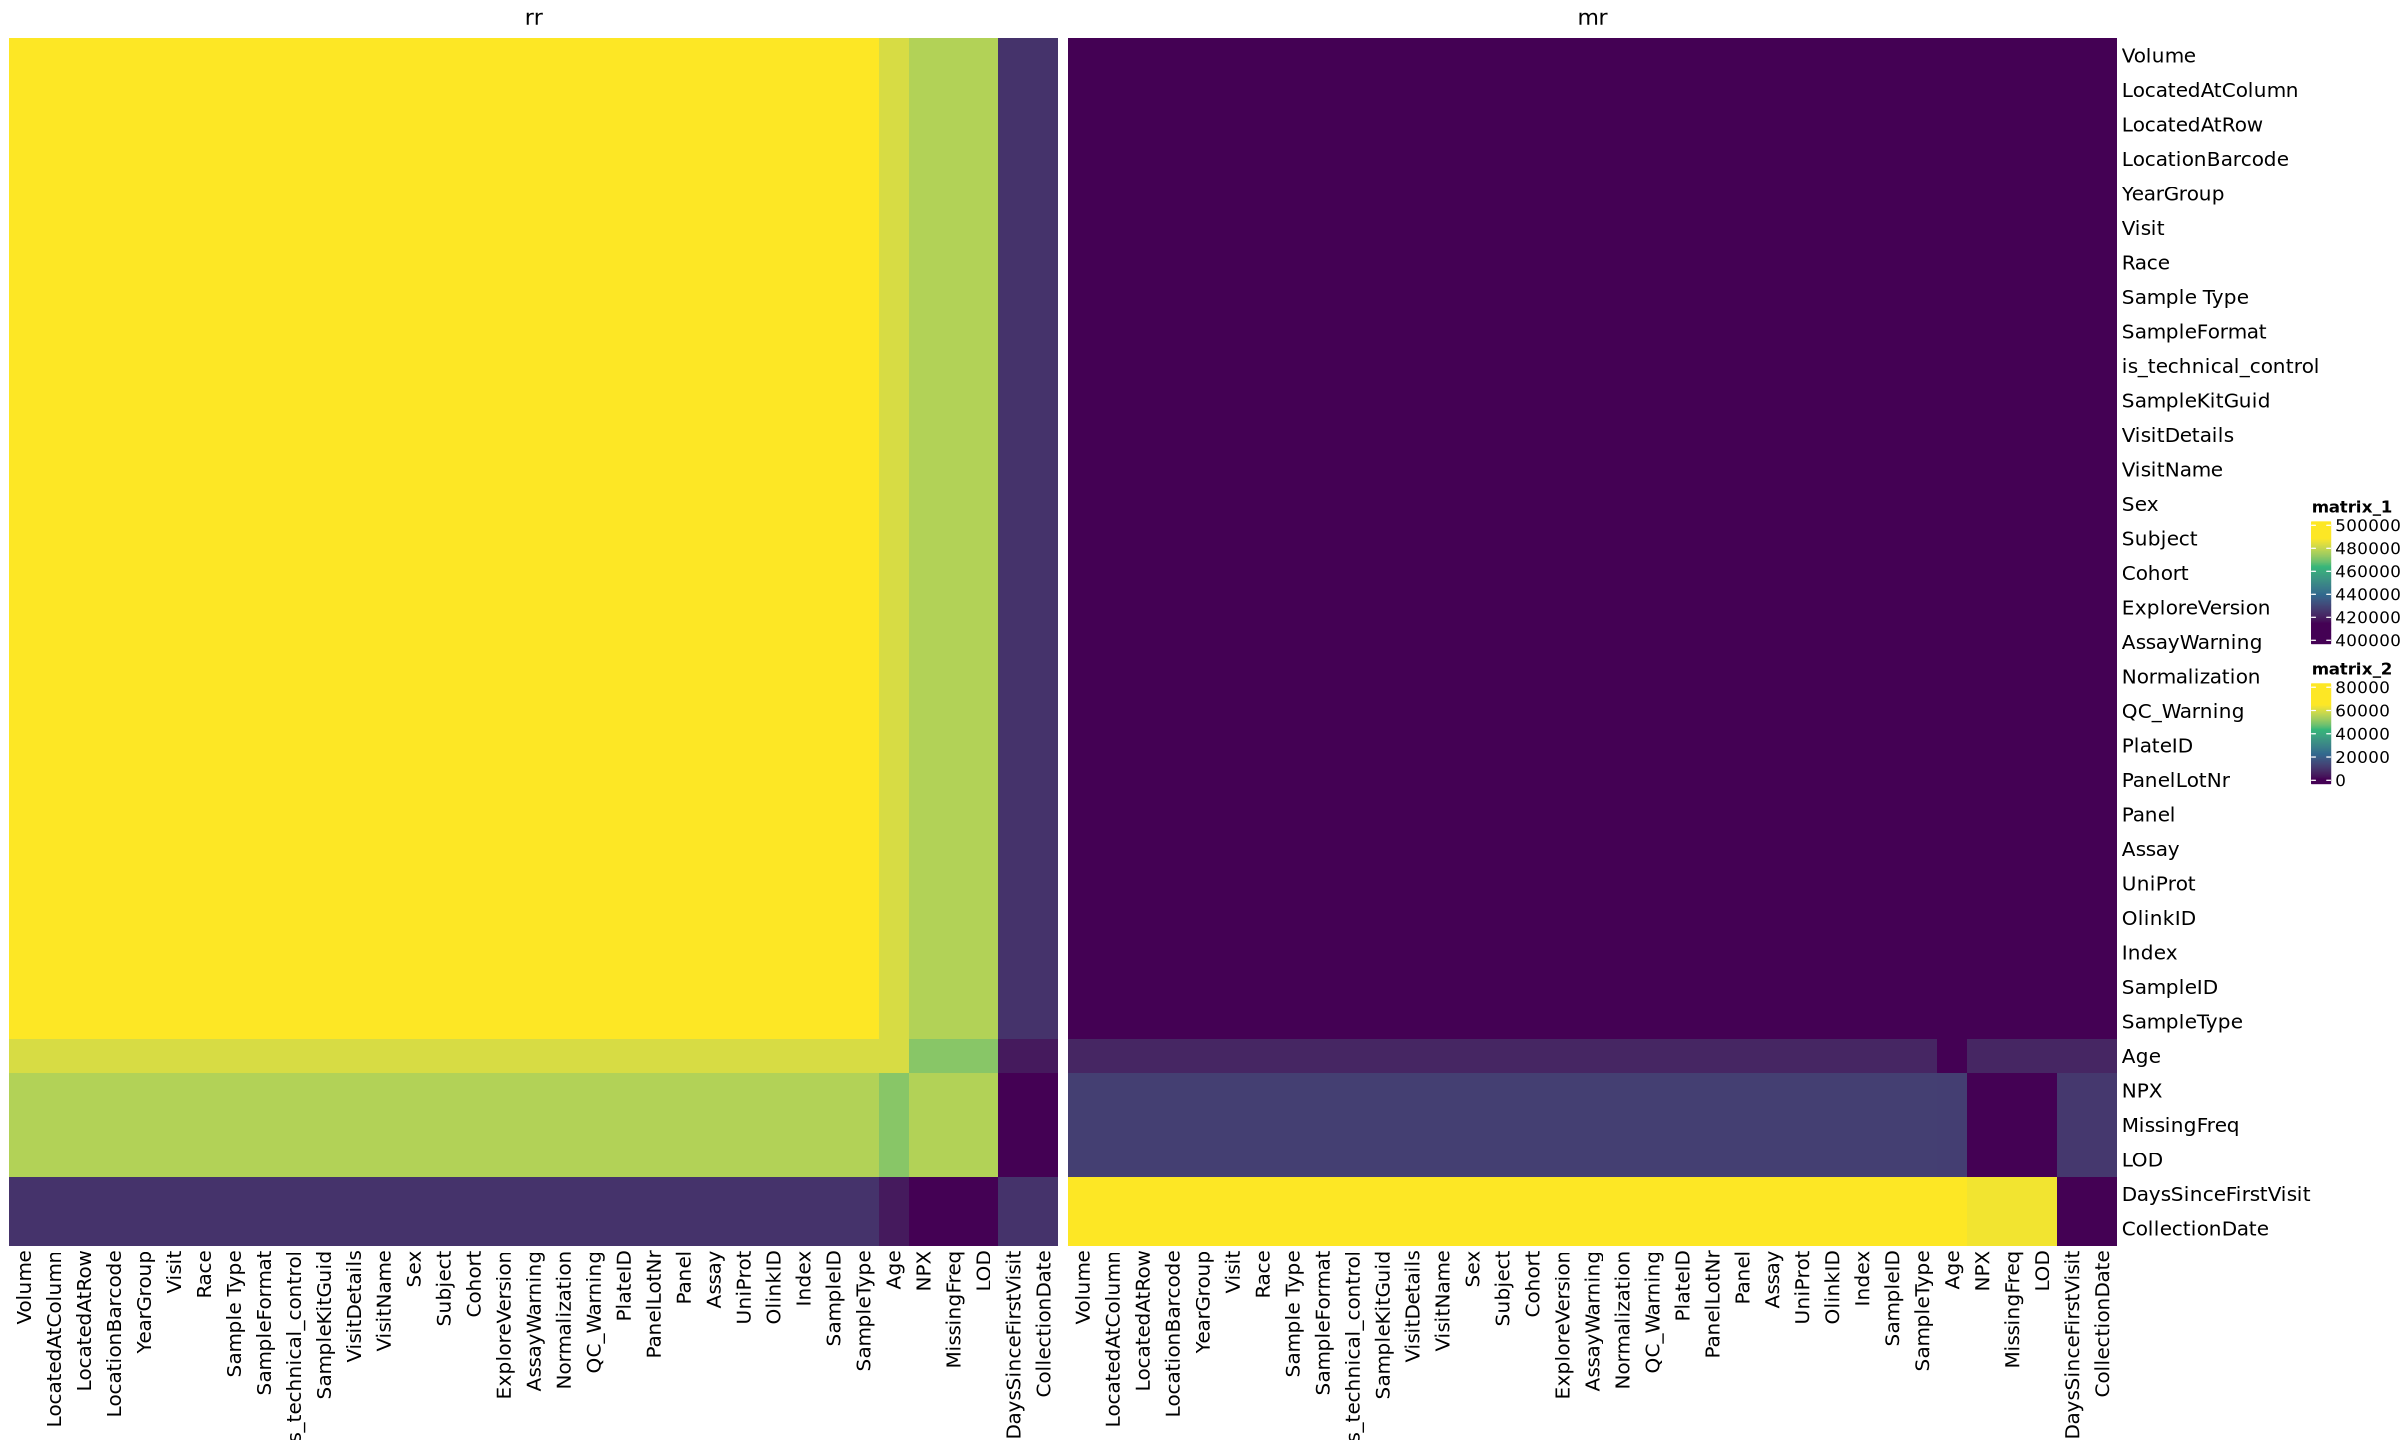

In [24]:
suppressPackageStartupMessages(library(ComplexHeatmap))
options(repr.plot.width = 20, repr.plot.height = 12)
missing.heatmap <- function(md_pairs, name) {
  ComplexHeatmap::Heatmap(md_pairs, column_title = name, col = viridis::viridis(4), cluster_rows = T, cluster_columns = T, show_row_dend = F, show_column_dend = F)
}

missing.heatmap(md_pairs.samples$rr, "rr") + missing.heatmap(md_pairs.samples$mr, "mr") 

In the heatmap of missing values above, we can see that in the left one (rr - response response) we see the number of rows with complete pairs and in the right one (mr - missing respons) where one variable is missing. CollectionDate and YearGroup have missingness and is likely attributable to the one subject seen earlier. However, it is easier seen in the mr heatmap that in general, they are not associated with missingness in other columns.  

## Join with sample KIT & specimen type meta data from hise

Download the hise data. We will then use a routine provided by Lauren to check for specimen data as this is not collected when converting to a data.frame from the list of file descriptors with the hise routine.

Get descriptors for all for all Olink SampleTypes in hise. 

In [25]:
fh1_filter_list <- list(
    cohort.cohortGuid = "FH1"
)

olink.descriptors.lists <- hise::getFileDescriptors(fileType = "Olink", 
                                                    filter=fh1_filter_list)

Get specimen data with Okada's script

In [26]:
hise.meta <- get_specimen_key(olink.descriptors.lists)

We are only interested in the BM samples. Remove duplicate rows. 

In [28]:
hise.meta %>% pull(specimenType) %>% unique()
hise.meta.bm <- hise.meta %>% filter(specimenType == "BMIF") %>% distinct()
head(hise.meta.bm,3)

[1] "Fixed cells"     "BMMC"            "Supernatant"     "Sample Pool"    
 [5] "Plasma"          "PBMC"            "Whole Blood"     "Tissue - Intact"
 [9] "Cell Pellet"     "BMIF"            ""                "CyTOF"          
[13] "Tempus Tube"     "Purified Cells"

,specimenGuid,specimenType,sample.sampleKitGuid
,<chr>,<chr>,<chr>
1,SUP02420-001-003,BMIF,KT02420
2,SUP02420-001-001,BMIF,KT02420
3,SUP02619-001-001,BMIF,KT02619


In [29]:
hise.meta.bm.dupes <- janitor::get_dupes(hise.meta.bm, specimenGuid)
hise.meta.bm.dupes %>% blame.dupes("specimenGuid")

No duplicate combinations found of: specimenGuid



specimenGuid,cols_to_blame,dupe_count
<chr>,<chr>,<int>


Join the meta data from hise with the earlier joined data. 

In [30]:
names(hise.meta.bm)
olink_bmif_joined <- left_join(olink_bmif_joined, hise.meta.bm, by=join_by(SampleID == specimenGuid), relationship = "many-to-one")

[1] "specimenGuid"         "specimenType"         "sample.sampleKitGuid"

,1,2,3,4,5,6
SampleID,BMIF02603-001-001,BMIF02604-001-003,SUP02433-001-003,SUP02438-001-003,BMIF04753-001-001,BMIF02617-001-001
SampleType,SAMPLE,SAMPLE,SAMPLE,SAMPLE,SAMPLE,SAMPLE
Index,1,2,3,4,6,7
OlinkID,OID21161,OID21161,OID21161,OID21161,OID21161,OID21161
UniProt,P22307,P22307,P22307,P22307,P22307,P22307
Assay,SCP2,SCP2,SCP2,SCP2,SCP2,SCP2
MissingFreq,0.753,0.753,0.753,0.753,0.753,0.753
Panel,Oncology,Oncology,Oncology,Oncology,Oncology,Oncology
PanelLotNr,B23406,B23406,B23406,B23406,B23406,B23406
PlateID,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887


# Write file

In [32]:
file.name <- "Olink_BM_with_hise_descriptors_08-18-2025.csv"
data.output.path <- file.path("../data", file.name)
write.csv(olink_bmif_joined, data.output.path)

In [32]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] magrittr_2.0.3     patchwork_1.2.0    data.table_1.17.8  ggpubr_0.6.1      
 [5] lme4_1.1-35.5      Matrix_1.6-5       OlinkAnalyze_4.3.1 vcd_1.4-13        
 [9] lubridate_1.9.3    forcats_1.0.0      stringr_1.5.1      dplyr_1.1.4       
[13] purrr_1.1.0        readr_2.1.5        tidyr_1.3.1   